# Chemical map generation

Model application on image to generate chemical map

## Loading spectra

In [ ]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

filepath = "data/1A.mat"
mat = scipy.io.loadmat(filepath)

In [31]:
red = 575
green = 535
blue = 445

def find_closest_index(target, array):
    array = np.asarray(array)
    idx = np.abs(array - target).argmin()
    return idx

def create_pseudo_rgb_image(hyperspectral_image, wavelengths):
    r_index = find_closest_index(red,wavelengths)
    g_index = find_closest_index(green,wavelengths)
    b_index = find_closest_index(blue,wavelengths)
    rgb_img = np.stack([
        hyperspectral_image[:, :, r_index],
        hyperspectral_image[:, :, g_index],
        hyperspectral_image[:, :, b_index]
    ], axis=-1)

    norm_img = np.empty_like(rgb_img, dtype=np.float32)

    # Normalize each channel independently
    for i in range(3):
        channel = rgb_img[:, :, i]
        vmin = np.percentile(channel, 1)
        vmax = np.percentile(channel, 99)
        norm_img[:, :, i] = np.clip((channel - vmin) / (vmax - vmin), 0, 1)

    # Convert to uint8
    rgb_uint8 = (norm_img * 255).astype(np.uint8)
    return rgb_uint8

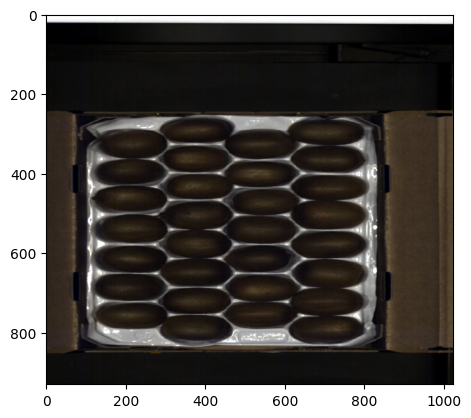

In [32]:
rgb_img = create_pseudo_rgb_image(mat["img"], mat["Wavelength"])
fig = plt.figure()
plt.imshow(rgb_img)

hyperspectral_img = mat["img"]
wavelengths = mat["Wavelength"]

In [33]:
import torch
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator
import supervision as sv

DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f"DEVICE = {DEVICE}")

MODEL_TYPE = "vit_h"
SAM_SAM_CHECKPOINT_PATH = "weights/sam_vit_h_4b8939.pth"

sam = sam_model_registry[MODEL_TYPE](checkpoint=SAM_SAM_CHECKPOINT_PATH).to(device=DEVICE)
mask_generator = SamAutomaticMaskGenerator(sam)
sam_result = mask_generator.generate(rgb_img)
sam_detections = sv.Detections.from_sam(sam_result=sam_result)

DEVICE = cuda:0


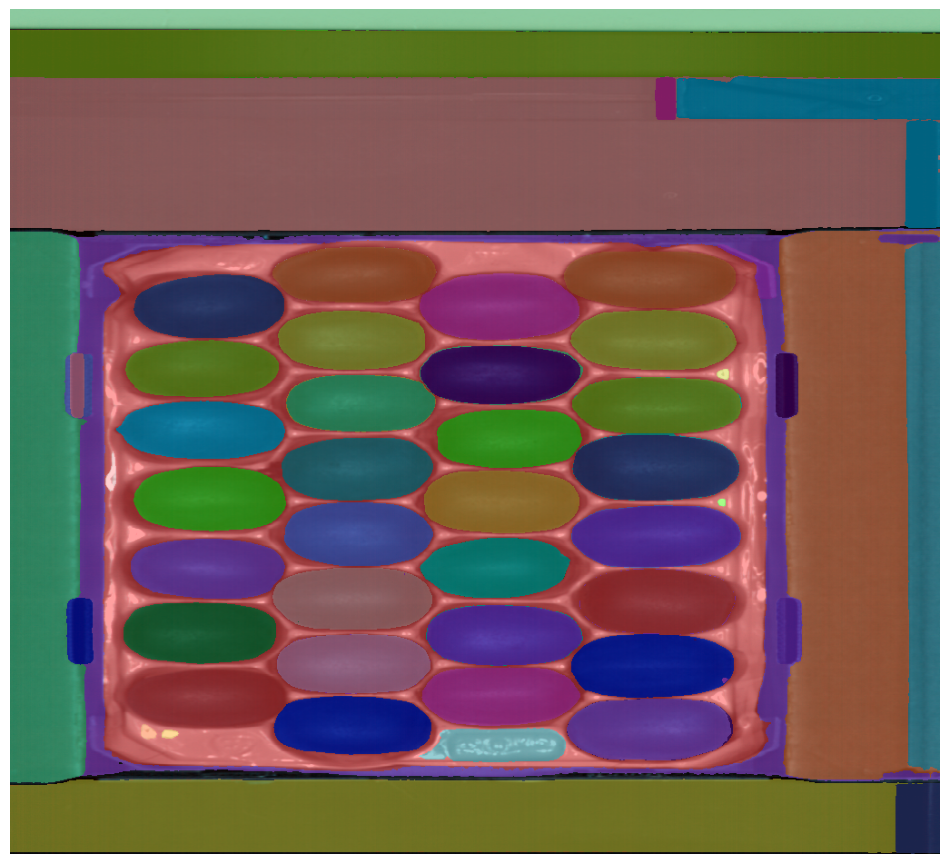

In [34]:
mask_annotator = sv.MaskAnnotator(color_lookup = sv.ColorLookup.INDEX)
sam_result = mask_annotator.annotate(scene=rgb_img.copy(), detections=sam_detections)
sv.plot_image(image=sam_result)

In [35]:
min_height = 40
max_height = 100
min_width = 150
max_width = 200

def make_sv_detections(masks, xyxy):
    return sv.Detections(xyxy=np.array(xyxy), mask=np.stack(masks))

def filter_masks_by_size(detections):
    filtered_masks = []
    filtered_xyxy = []
    for detection in detections:
        mask = detection[1]
        xyxy = detection[0]
        y_coords, x_coords = np.where(mask)
        height = y_coords.max() - y_coords.min() + 1
        width = x_coords.max() - x_coords.min() + 1

        if min_height <= height <= max_height and min_width <= width <= max_width:
            filtered_masks.append(mask)
            filtered_xyxy.append(xyxy) 
    return make_sv_detections(filtered_masks, filtered_xyxy)

filtered_detections = filter_masks_by_size(sam_detections)

In [36]:
def remove_overlapping_masks(detections):
    occupied = np.zeros_like(detections.mask[0], dtype=bool)
    non_overlapping_masks = []
    non_overlapping_xyxy = []

    for mask, box in zip(detections.mask, detections.xyxy):
        if not np.any(mask & occupied):
            non_overlapping_masks.append(mask)
            non_overlapping_xyxy.append(box)
            occupied |= mask  # Mark this area as taken

    if not non_overlapping_masks:
        return sv.Detections(xyxy=np.empty((0, 4)), mask=np.empty((0, *detections.mask[0].shape), dtype=bool))

    filtered_xyxy = np.array(non_overlapping_xyxy)
    filtered_masks = np.stack(non_overlapping_masks)

    return sv.Detections(xyxy=filtered_xyxy, mask=filtered_masks)


filtered_detections = remove_overlapping_masks(filtered_detections)

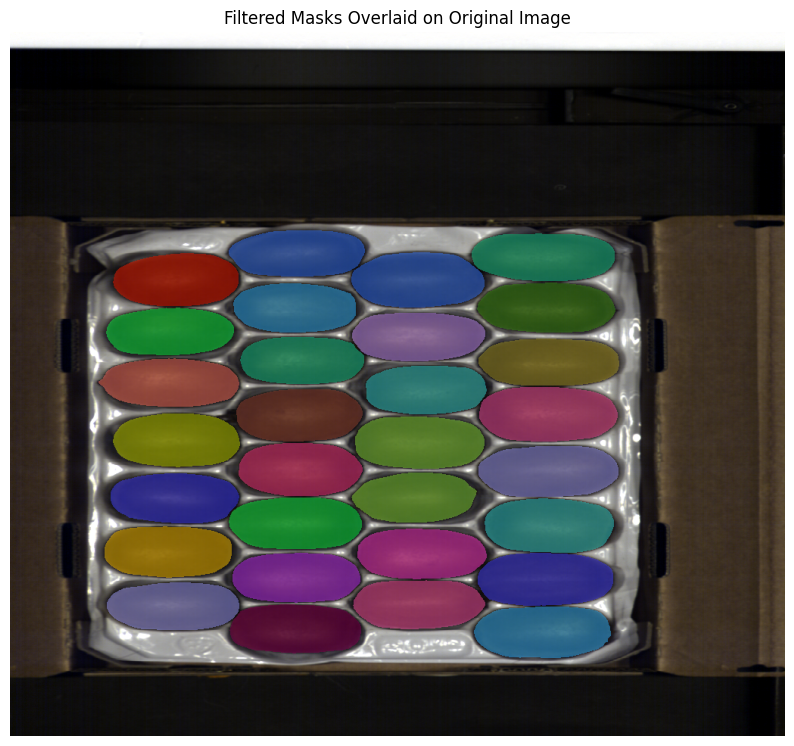

In [37]:
# Create the annotated image
annotated_img = mask_annotator.annotate(scene=rgb_img.copy(), detections=filtered_detections)

# Plot the original image with overlaid masks
plt.figure(figsize=(10, 10))
plt.imshow(annotated_img)
plt.axis("off")
plt.title("Filtered Masks Overlaid on Original Image")
plt.show()

## PLS Regression

In [38]:
import joblib

plsr = joblib.load('results/plsr_model.pkl')

## Load image & segmenting with sam

Crop around mask of one fruit 

Do prediction for each pixel (on pre-processed spectra belonging to that pixel) - either flatten pixels and then bring them back to their normal shape

Plot the image with prediction

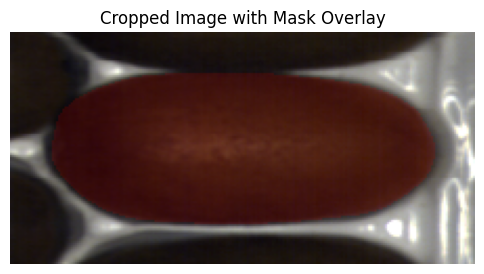

In [43]:
import numpy as np

# Choose the detection you're interested in (e.g., the first one)
chosen_idx = 0
mask = filtered_detections.mask[chosen_idx]
xyxy = filtered_detections.xyxy[chosen_idx]
x_min, y_min, x_max, y_max = xyxy

# Add margin (e.g., 20 pixels)
margin = 20
y_min = max(0, y_min - margin)
y_max = min(rgb_img.shape[0], y_max + margin)
x_min = max(0, x_min - margin)
x_max = min(rgb_img.shape[1], x_max + margin)

# Crop the original image
cropped_img = rgb_img[y_min:y_max, x_min:x_max]

# Crop the mask just like the image
cropped_mask = mask[y_min:y_max, x_min:x_max]

# Create an RGB version of the cropped image
cropped_img_rgb = cropped_img.copy()

# Overlay: for example, make masked areas reddish
overlay = cropped_img_rgb.copy()
overlay[cropped_mask] = [255, 0, 0]  # Red color

# Blend original and overlay
alpha = 0.15  # Transparency
blended = (cropped_img_rgb * (1 - alpha) + overlay * alpha).astype(np.uint8)

# Plot
plt.figure(figsize=(6, 6))
plt.imshow(blended)
plt.title("Cropped Image with Mask Overlay")
plt.axis("off")
plt.show()

In [54]:
X_mask = hyperspectral_img[y_min:y_max, x_min:x_max, :]
height, width, bands = X_mask.shape
X_mask_reshaped = X_mask.reshape(-1, X_mask.shape[2])

In [55]:
X_mask_reshaped.shape

(24642, 224)

In [56]:
import nippy

preprocessing_pipeline = {'MSC': None, 
                          'SAVGOL': 
                          {'deriv_order': 2, 
                           'filter_win': 13, 
                           'poly_order': 2}, 
                           'SNV': {}}

wl, X_mask_reshaped_processed = nippy.run_pipeline(wavelengths, X_mask_reshaped.T, preprocessing_pipeline)
X_mask_reshaped_processed = X_mask_reshaped_processed.T

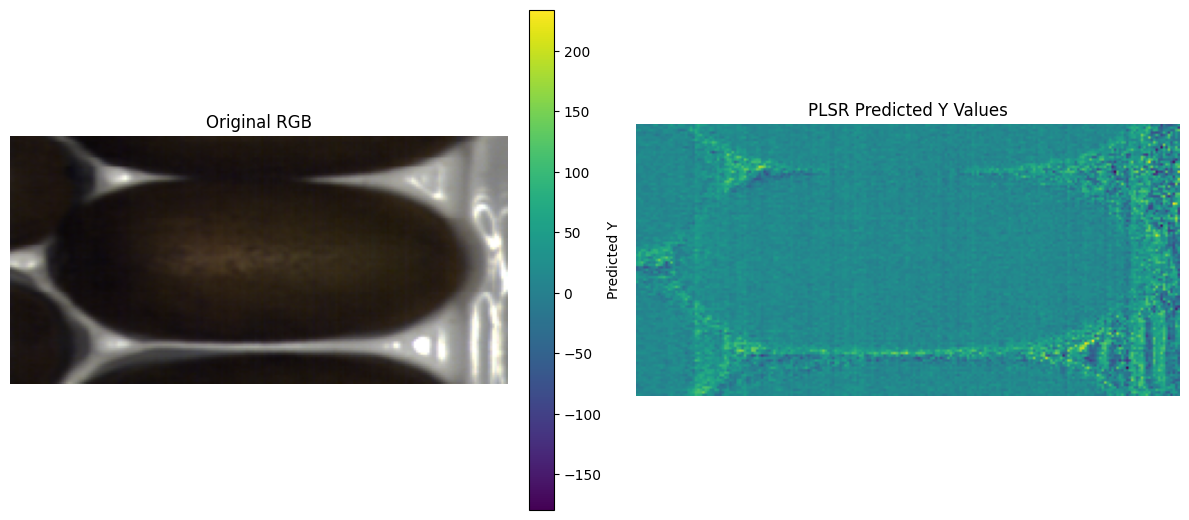

In [66]:
import matplotlib.cm as cm

y_mask = plsr.predict(X_mask_reshaped_processed)
y_mask_restored_shape = y_mask.reshape((height, width))

# Set color range based on actual values
vmin = np.min(y_mask_restored_shape) 
vmax = np.max(y_mask_restored_shape)

# Create figure with two subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# --- Plot 1: Original RGB image ---
axs[0].imshow(cropped_img_rgb)
axs[0].set_title("Original RGB")
axs[0].axis("off")

# --- Plot 2: PLSR heatmap with colorbar ---
im = axs[1].imshow(y_mask_restored_shape, cmap='viridis', vmin=vmin, vmax=vmax)
axs[1].set_title("PLSR Predicted Y Values")
axs[1].axis("off")

# Add colorbar to the first subplot
cbar = plt.colorbar(im, ax=axs[0], fraction=0.046, pad=0.04)
cbar.set_label("Predicted Y")

plt.tight_layout()
plt.show()

## Validation of chemical maps

Similarity, heterogeneity (paper and code comes later)